# DATA ANALYTICS IN PYTHON - MINI PROJECT

## Name: Mehul Vig
## Class: CSE 4
## Enrollment No. : 240537
## Course Code : CSE2101

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

from scipy.stats import ttest_ind, skew, kurtosis, norm

## Problem definition and Data Selection

- DATASET: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard/data
- About Dataset
- Uber Ride Analytics Dataset 2024: This comprehensive dataset contains detailed ride-sharing data from Uber operations for the year 2024, providing rich insights into booking patterns, vehicle performance, revenue streams, cancellation behaviors, and customer satisfaction metrics.
- Dataset Overview: The dataset captures 148,770 total bookings across multiple vehicle types and provides a complete view of ride-sharing operations including successful rides, cancellations, customer behaviors, and financial metrics.
- Key Statistics:
1. Total Bookings: 148.77K rides
2. Success Rate: 65.96% (93K completed rides)
3. Cancellation Rate: 25% (37.43K cancelled bookings)
4. Customer Cancellations: 19.15% (27K rides)
5. Driver Cancellations: 7.45% (10.5K rides)



In [3]:
data = pd.read_csv('ncr_ride_bookings.csv')

In [4]:
data

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [6]:
dim = data.shape

print("Data has", dim[1], "columns and", dim[0], "rows")

Data has 21 columns and 150000 rows


In [7]:
data.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

## 2. Data Cleaning & Preparation

In [8]:
df = pd.DataFrame(data)

In [9]:
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [10]:
df = df.drop_duplicates()

In [11]:
print('After removing duplicates: ')
df.info()

After removing duplicates: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for 

In [12]:
print('No duplicate value is there since the number remains same')

No duplicate value is there since the number remains same


In [13]:
print('The data is already standardised')

The data is already standardised


In [14]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


### 2.1 Handling Missing Values

In [15]:
# finding null values
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

#### A. Filling NULL values using **ZERO** imputation

In [16]:
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna("none")
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna("none")
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0)
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna("none")

#### B. Filling NULL values using **MEAN** imputation

In [17]:
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg CTAT'].mean())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].mean())
df['Booking Value'] = df['Booking Value'].fillna(df['Booking Value'].mean())
df['Ride Distance'] = df['Ride Distance'].fillna(df['Ride Distance'].mean())
df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].mean())
df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].mean())
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])

In [18]:
# Verifying the NaN values per column
df.isnull().sum()

Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
Payment Method                       0
dtype: int64

#### C. Handling Datatypes


- Datatype for **DateTime**

In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time']= pd.to_datetime(df['Time'])
df["Day"] = df["Date"].dt.day_name()
df['Month_name'] = df['Date'].dt.month_name()
df['Hour']= df['Time'].dt.hour

- Datatype Handling for **categorical values**

In [23]:
df['Booking ID'] = df['Booking ID'].astype('string')
df['Booking Status'] = df['Booking Status'].astype('string')
df['Customer ID'] = df['Customer ID'].astype('string')
df['Vehicle Type'] = df['Vehicle Type'].astype('string')
df['Pickup Location'] = df['Pickup Location'].astype('string')
df['Drop Location'] = df['Drop Location'].astype('string')
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].astype('string')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].astype('string')
df['Incomplete Rides'] = df['Incomplete Rides'].astype('int')
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].astype('string')
df['Payment Method'] = df['Payment Method'].astype('string')

df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].astype('int')
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].astype('int')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  datetime64[ns]
 2   Booking ID                         150000 non-null  string        
 3   Booking Status                     150000 non-null  string        
 4   Customer ID                        150000 non-null  string        
 5   Vehicle Type                       150000 non-null  string        
 6   Pickup Location                    150000 non-null  string        
 7   Drop Location                      150000 non-null  string        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

### 2.3 Handle outliers using suitable methods (IQR, z-score, etc.).

In [25]:
# Make a copy BEFORE modifying anything
df_before_capping = df.copy()

selected_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in selected_cols:
    Q1 = df_before_capping[col].quantile(0.25)
    Q3 = df_before_capping[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Apply capping to df (AFTER saving df_before_capping)
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


### Boxplot Visualization for outliers

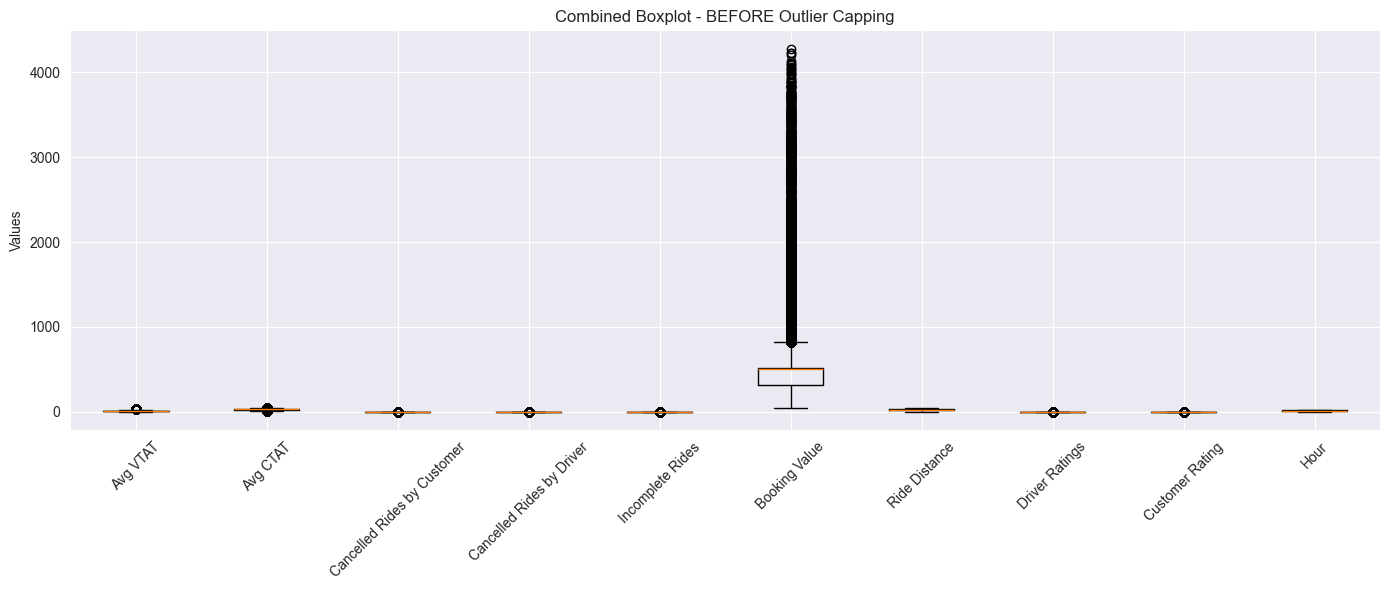

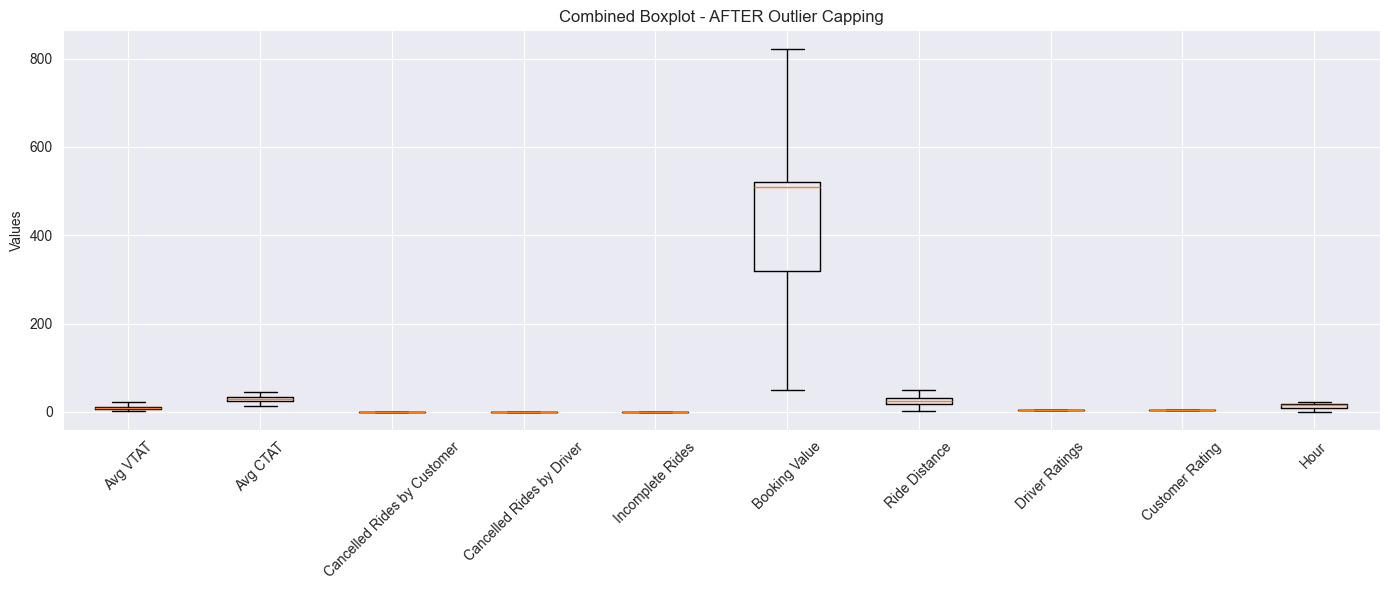

In [26]:
numeric_cols = df_before_capping.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 6))
plt.boxplot([df_before_capping[col].dropna() for col in numeric_cols],
            tick_labels=numeric_cols)
plt.title("Combined Boxplot - BEFORE Outlier Capping")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols],
            tick_labels=numeric_cols)
plt.title("Combined Boxplot - AFTER Outlier Capping")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 2.4 Encode categorical data

In [27]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    if df[col].nunique() <= 2:
        df[col] = le.fit_transform(df[col])
    else:
        df = pd.get_dummies(df, columns=[col])

#### 2.5 The data is already NORMALISED.

In [33]:
df.to_csv("uber_data.csv", index=False)

## Conclusion for Data Preprocessing

## 3. EDA Exploratory Data Analysis

### 3.1 Univariate analysis

In [25]:
Avg_distance_ride = round(df['Ride Distance'].mean(),2)
Avg_booking_value = round(df['Booking Value'].mean(),2)
Avg_driver_rating = round(df['Driver Ratings'].mean(),2)
Avg_customer_rating = round(df['Customer Rating'].mean(),2)
Avg_VTAT = round(df['Avg VTAT'].mean(),2)
Avg_CTAT = round(df['Avg CTAT'].mean(),2)

In [26]:
print(f'Average Ride Distance: {Avg_distance_ride} kms \n')
print(f'Average Booking Value: ₹ {Avg_booking_value} \n')
print(f'Average Driver Rating: {Avg_driver_rating}')
print(f'Average Customer Rating: {Avg_customer_rating}\n')
print(f'Average VTAT: {Avg_VTAT}')
print(f'Average CTAT: {Avg_CTAT}')

Average Ride Distance: 24.64 kms 

Average Booking Value: ₹ 468.42 

Average Driver Rating: 4.25
Average Customer Rating: 4.43

Average VTAT: 9.38
Average CTAT: 29.16


#### A.Rush Hour Calculation

In [27]:
def is_rush_hour(hour):
  if  hour > 7 and hour < 10:
    return 1
  elif hour > 17 and hour < 21:
    return 1
  else:
    return 0

df['Rush Hour'] = df['Hour'].apply(is_rush_hour)

def time_of_day(hour):
  if  hour> 7 and hour < 12:
    return 'Morning'

  elif hour> 12 and hour < 17:
    return 'Afternoon'

  elif hour> 17 and hour < 21:
    return 'Evening'

  else:
    return 'Night'

df['Time of Day'] = df['Hour'].apply(time_of_day)

In [28]:
df['Rush Hour'] = df['Rush Hour'].map({0: 'No Rush', 1: 'Rush'})
counts = df['Rush Hour'].value_counts()

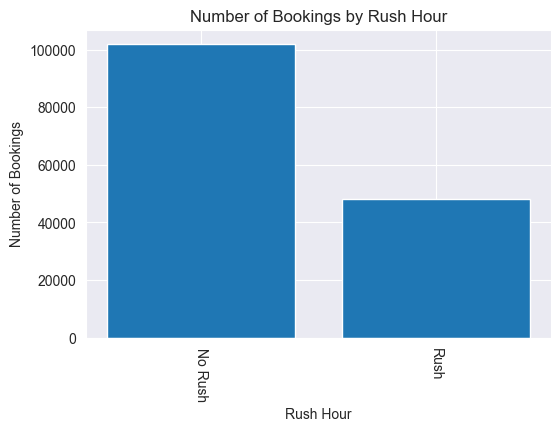

In [29]:
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=-90)
plt.xlabel('Rush Hour')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings by Rush Hour')
plt.show()

- Conclusion : The maximum bookings takes place during the no rush hour as the prices are less during that time

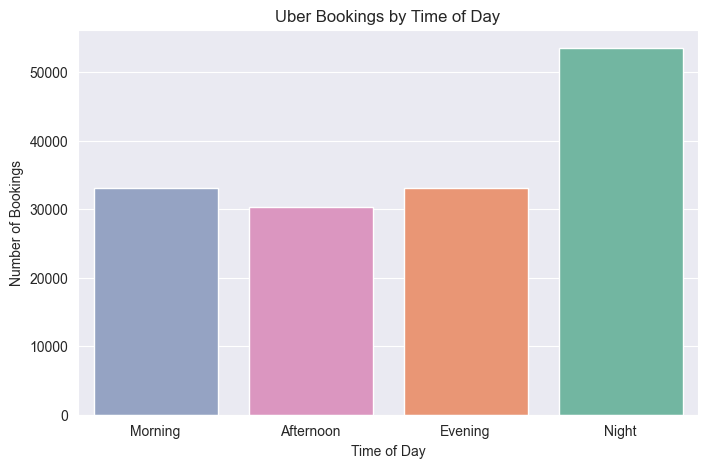

In [30]:
# Bookings of the day
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Time of Day', hue='Time of Day', order=['Morning','Afternoon','Evening','Night'], palette="Set2")
plt.title("Uber Bookings by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Bookings")
plt.show()

- Conclusion : Maximum bookings are made during the night time.

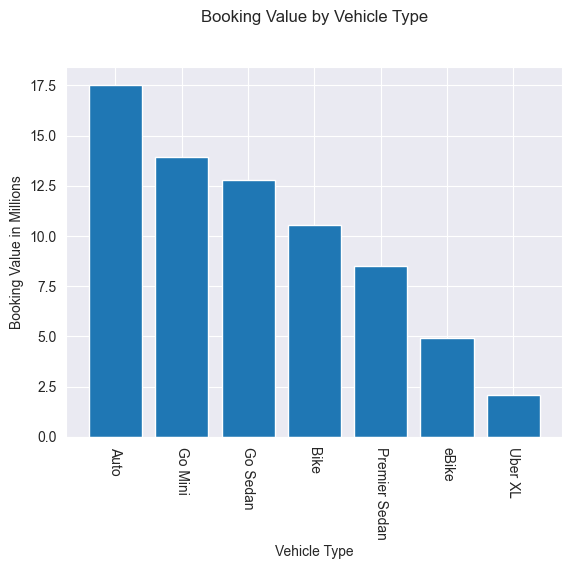

In [31]:
# Vehicle Type Preference
vehicle_type = df.groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)
plt.bar(vehicle_type.index, vehicle_type.values/1000000)
plt.xticks(rotation=-90)
plt.xlabel('Vehicle Type')
plt.ylabel('Booking Value in Millions')
plt.title('Booking Value by Vehicle Type',y=1.1)
plt.show()

- Conclusion: Auto is the most preferred choice of the customers to travel, followed by the Go mini (as the price for these vehicles is comparatively cheaper.

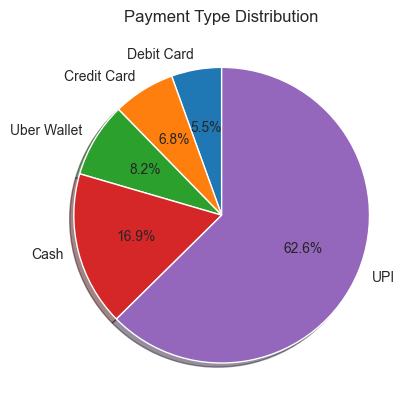

In [32]:
# Payment Method Distribution
payment_type = df.groupby('Payment Method')['Payment Method'].count().sort_values(ascending=True)
plt.pie(payment_type, labels=payment_type.index ,autopct='%1.1f%%',shadow=True,normalize=True,startangle=90)
plt.title('Payment Type Distribution')
plt.show()

- Conclusion : The most preferred choice by the customers for payment is UPI, followed by Cash

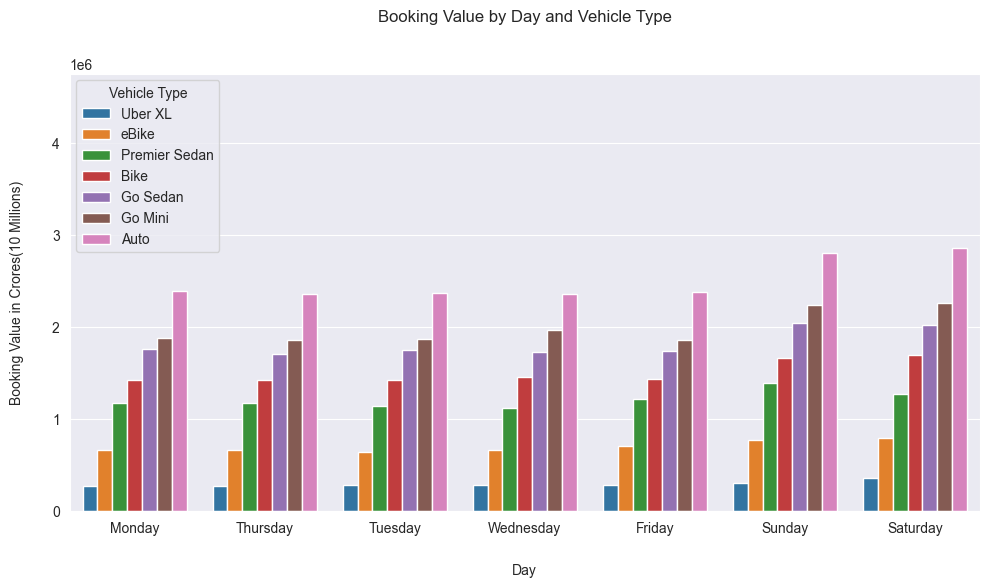

In [32]:
day_booking_value = (
    df.groupby(['Day', 'Vehicle Type'])['Booking Value']
      .sum()
      .reset_index().sort_values('Booking Value')
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=day_booking_value,
    x='Day',
    y='Booking Value',
    hue='Vehicle Type',
    palette='tab10'
)

plt.ylim(0,day_booking_value['Booking Value'].max()+1900000)
plt.title("Booking Value by Day and Vehicle Type",y=1.1)
plt.xlabel('Day',labelpad=20.2)
plt.ylabel('Booking Value in Crores(10 Millions)' ,labelpad=20.2)
plt.tight_layout()
plt.show()

- Conclusion : Auto is the most preferred choice for the customers. Also in weekends the demand for Premier Sedan Rises

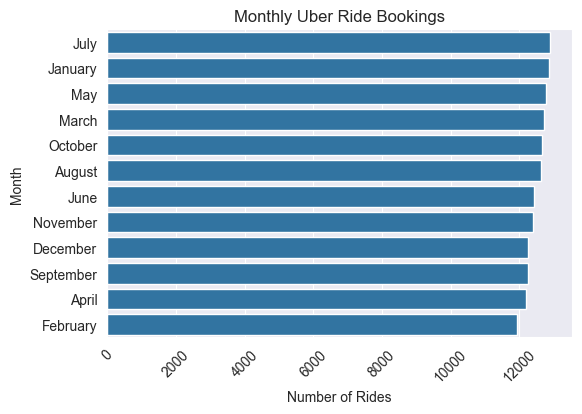

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, y='Month_name', order=df['Month_name'].value_counts().index)
plt.title("Monthly Uber Ride Bookings")
plt.xlabel("Number of Rides")
plt.ylabel("Month")
plt.xticks(rotation=45)
plt.show()

- Conclusion :  _High_ demand in **July** , **January** and **May**

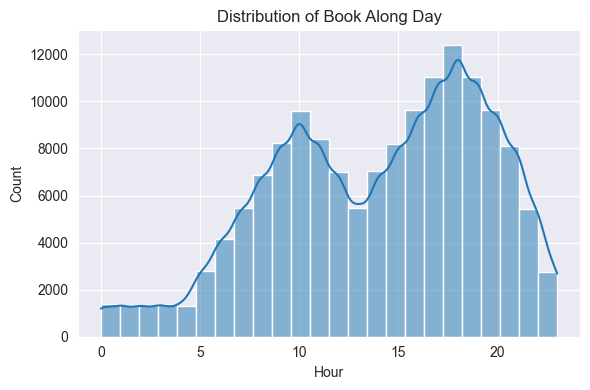

In [37]:
plt.figure(figsize=(6,4))
sns.histplot(
    data = df["Time"].dt.hour,
    bins = 24,
    kde = True,
)
plt.title("Distribution of Book Along Day")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

- Conclusion : Booking _peaked_ two times first between **9 to 10 AM** then between **7 to 8 PM**

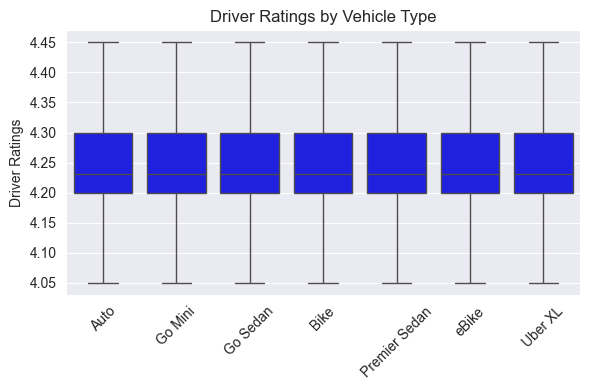

In [38]:
plt.figure(figsize=(6,4))
order = ['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL']
sns.boxplot(
    data=df,
    x="Vehicle Type",
    y="Driver Ratings",
    order=order,
    color="b",
    showfliers=False
)
plt.title("Driver Ratings by Vehicle Type")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


-  Conclusion: All vehicle types show high driver ratings most **median values** hover around **4.2** to **4.4** out of 5 means **uniform driver performance**

In [39]:
df['Day_type'] = df['Day'].apply(lambda x: 'weekend' if x in ['Saturday', 'Sunday'] else 'weekday')

print("'Day_type' column added successfully!")
df[['Day', 'Day_type']].head()

'Day_type' column added successfully!


,Day,Day_type
0,Saturday,weekend
1,Friday,weekday
2,Friday,weekday
3,Monday,weekday
4,Monday,weekday


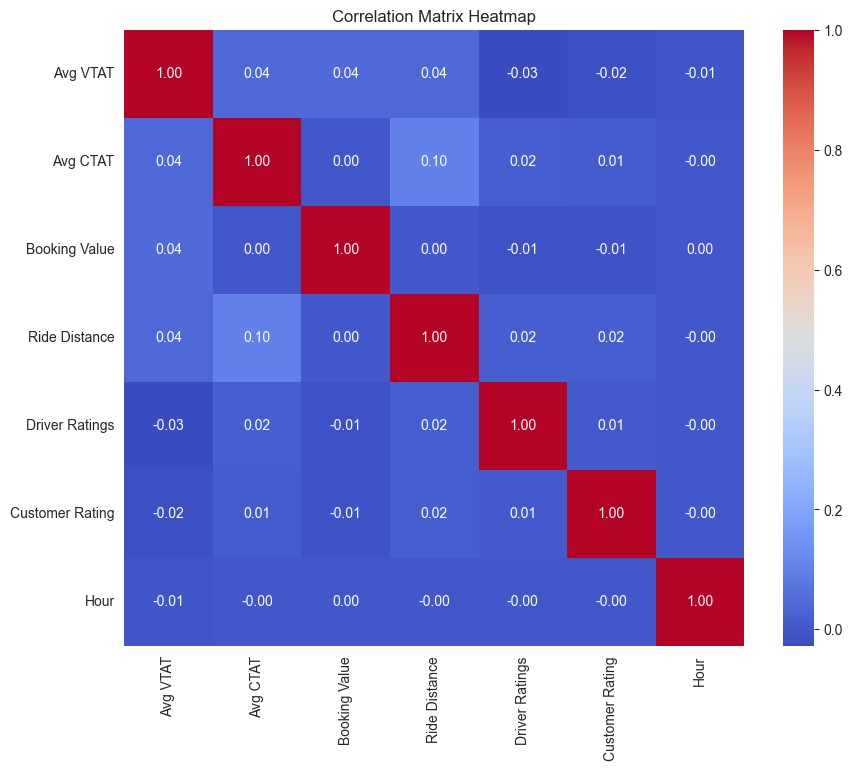

In [40]:

# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Columns to exclude from the heatmap
columns_to_exclude = [
    'Cancelled Rides by Driver',
    'Incomplete Rides',
    'Cancelled Rides by Customer'
]

# Drop the columns if they exist in the dataframe
numeric_df_filtered = numeric_df.drop(columns=[col for col in columns_to_exclude if col in numeric_df.columns])

# Compute correlation matrix
corr_matrix = numeric_df_filtered.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

## 4.Statistical Analysis & Hypothesis Testing

#### 4.1 Statistical Analysis

In [41]:
col = 'Hour'

print(f"DESCRIPTIVE STATISTICS for '{col}':")
mean = df[col].mean()
median = df[col].median()
std = df[col].std()
skewness = skew(df[col].dropna())
kurt = kurtosis(df[col].dropna(), fisher=True)

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurt:.3f}")

# Data distribution interpretation
if abs(skewness) < 0.5:
    skew_comment = "roughly symmetric"
elif skewness > 0:
    skew_comment = "right-skewed"
else:
    skew_comment = "left-skewed"

if kurt > 3:
    kurt_comment = "heavy tails (leptokurtic)"
elif kurt < 3:
    kurt_comment = "light tails (platykurtic)"
else:
    kurt_comment = "mesokurtic (similar to normal)"

print(f"\nDistribution is {skew_comment} and has {kurt_comment}.")


DESCRIPTIVE STATISTICS for 'Hour':
Mean: 14.03
Median: 15.00
Standard Deviation: 5.42
Skewness: -0.416
Kurtosis: -0.652

Distribution is roughly symmetric and has light tails (platykurtic).


In [42]:
df.describe()['Hour']

count    150000.000000
mean         14.034113
min           0.000000
25%          10.000000
50%          15.000000
75%          18.000000
max          23.000000
std           5.416906
Name: Hour, dtype: float64

#### 4.2 Hypothesis Testing

In [43]:
# Compare 'Hour' across weekdays and weekends
group1 = df[df['Day_type'] == 'weekday'][col].dropna()
group2 = df[df['Day_type'] == 'weekend'][col].dropna()

# Independent t-test
t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
print(f"Mean :{mean.round(2)}")
print(f"T-test Results for '{col}' (Weekday vs Weekend):")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.4f}")

# Confidence Interval (95%)
mean_diff = group1.mean() - group2.mean()
se = np.sqrt(group1.var()/len(group1) + group2.var()/len(group2))
z_critical = norm.ppf(0.975)
ci_low = mean_diff - z_critical * se
ci_high = mean_diff + z_critical * se

print(f"\n95% Confidence Interval for Difference in Means: ({ci_low:.2f}, {ci_high:.2f})")

Mean :14.03
T-test Results for 'Hour' (Weekday vs Weekend):
t-statistic = -0.802
p-value = 0.4226

95% Confidence Interval for Difference in Means: (-0.09, 0.04)


In [44]:
print("""Type II Error: Failing to reject the null hypothesis when it is actually false (a false negative).""")

Type II Error: Failing to reject the null hypothesis when it is actually false (a false negative).


##### **Hypothesis Test Results**:

- t-statistic = -0.802, p-value = 0.4226, mean = 14.03

- Since p > 0.05, we **fail to reject the null hypothesis**.
- There is **no** statistically significant difference between the **mean** Hour values for weekdays and weekends.

- Confidence Interval: (-0.09, 0.04)
- This interval includes 0 → reinforcing that the means are statistically similar.


##### **Conclusion**:

Trip timing (Hour) remains consistent across weekdays and weekends hence users book rides during **SIMILAR** hours regardless of the day type.

## 5. Modeling and Pattern Discovery

In [45]:
total_trips = len(df['Booking Status'])
completed_trips = df[df['Booking Status'] == 'Completed'].copy()
print("Total trips: ",total_trips)
print(f"Completed trips: {len(completed_trips)}")

Total trips:  150000
Completed trips: 93000


In [46]:
clustering_features = completed_trips[['Hour', 'Ride Distance']].dropna()
print(f"Rows with valid Duration and Distance: {len(clustering_features)}")

Rows with valid Duration and Distance: 93000


In [47]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(clustering_features)
completed_trips.loc[clustering_features.index, 'Cluster'] = cluster_labels

print("K-MEANS CLUSTERING MODEL RESULTS")
cluster_summary = completed_trips.groupby('Cluster')[['Hour', 'Ride Distance', 'Booking Value']].mean()
print("\nCluster Summary Statistics:")
print(cluster_summary)


K-MEANS CLUSTERING MODEL RESULTS

Cluster Summary Statistics:
              Hour  Ride Distance  Booking Value
Cluster                                         
0.0      13.966690      42.041610     449.758919
1.0      14.005904      10.118806     446.756259
2.0      14.119333      26.193192     452.233733


In [48]:
target = 'Booking Value'
features = ['Ride Distance', 'Hour']

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

In [49]:
# MODEL 1: K-NEAREST NEIGHBORS (KNN)

print("MODEL 1: K-NEAREST NEIGHBORS (KNN)")
print("Predicting Ride Cancellation (Cancelled = 1, Completed = 0)")
# Create binary target variable
df['Is_Cancelled'] = df['Booking Status'].apply(lambda x: 1 if 'Cancelled' in str(x) else 0)

# Select available features
knn_features = ['Ride Distance', 'Avg VTAT', 'Avg CTAT']
knn_features = [col for col in knn_features if col in df.columns]

X_knn = df[knn_features].fillna(df[knn_features].mean())
y_knn = df['Is_Cancelled']

print(f"\nFeatures used: {knn_features}")
print(f"Target: Is_Cancelled (0=Completed, 1=Cancelled)")
print(f"Total samples: {len(X_knn)}")
print(f"Cancelled rides: {(y_knn == 1).sum()}")
print(f"Completed rides: {(y_knn == 0).sum()}")


MODEL 1: K-NEAREST NEIGHBORS (KNN)
Predicting Ride Cancellation (Cancelled = 1, Completed = 0)

Features used: ['Ride Distance', 'Avg VTAT', 'Avg CTAT']
Target: Is_Cancelled (0=Completed, 1=Cancelled)
Total samples: 150000
Cancelled rides: 37500
Completed rides: 112500


In [50]:
# Split data
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.3, random_state=42
)

# Train KNN model (k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train_knn)

# Predictions
y_pred_knn = knn_model.predict(X_test_knn)


In [51]:
# Evaluate performance
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)


print("KNN MODEL RESULTS (k=5)")

print(f"\nAccuracy: {accuracy_knn:.3f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives (Completed):  {cm_knn[0, 0]}")
print(f"  False Positives (Cancelled): {cm_knn[0, 1]}")
print(f"  False Negatives (Completed): {cm_knn[1, 0]}")
print(f"  True Positives (Cancelled):  {cm_knn[1, 1]}")

print("\nClassification Report:")
print(classification_report(y_test_knn, y_pred_knn, target_names=['Completed', 'Cancelled']))

KNN MODEL RESULTS (k=5)

Accuracy: 0.999

Confusion Matrix:
  True Negatives (Completed):  33747
  False Positives (Cancelled): 26
  False Negatives (Completed): 0
  True Positives (Cancelled):  11227

Classification Report:
              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00     33773
   Cancelled       1.00      1.00      1.00     11227

    accuracy                           1.00     45000
   macro avg       1.00      1.00      1.00     45000
weighted avg       1.00      1.00      1.00     45000



In [52]:
print(f"\nAccuracy for different k values:")
print(f"k - Accuracy")

for k in range(1, 10):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_knn, y_train_knn)
    acc_temp = accuracy_score(y_test_knn, knn_temp.predict(X_test_knn))
    print(f"{k}  - {acc_temp}")



Accuracy for different k values:
k - Accuracy
1  - 0.9997333333333334
2  - 0.9997333333333334
3  - 0.9995333333333334
4  - 0.9995333333333334
5  - 0.9994222222222222
6  - 0.9994222222222222
7  - 0.9993111111111111
8  - 0.9993111111111111
9  - 0.9992222222222222


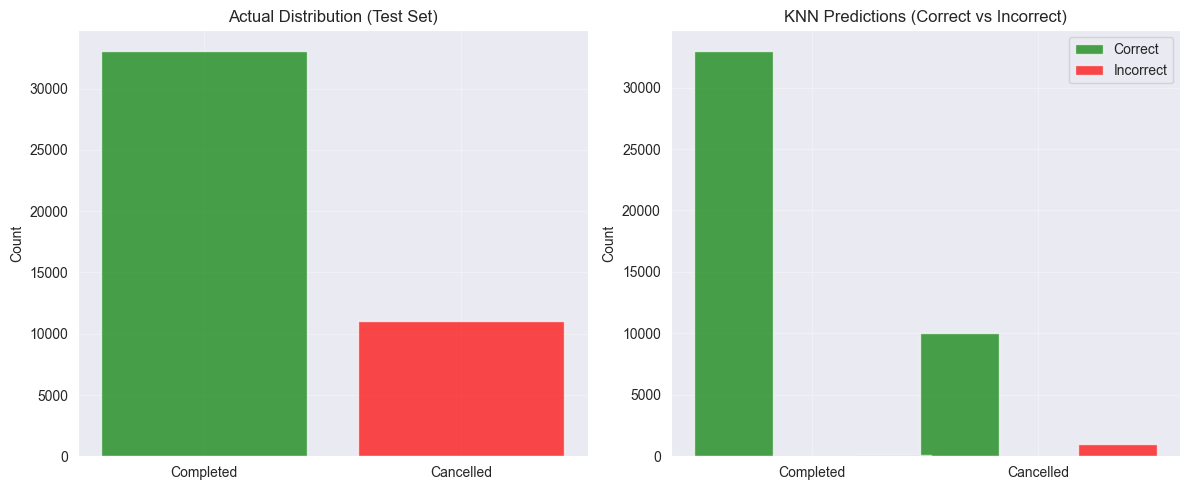

In [62]:
plt.figure(figsize=(12, 5))

# 1. Actual Distribution

plt.subplot(1, 2, 1)

actual_completed = cm_knn[0, 0] + cm_knn[0, 1]    # all rows where actual = Completed
actual_cancelled = cm_knn[1, 0] + cm_knn[1, 1]    # all rows where actual = Cancelled

plt.bar(['Completed', 'Cancelled'],
        [actual_completed, actual_cancelled],
        color=['green', 'red'],
        alpha=0.7)

plt.ylabel('Count')
plt.title('Actual Distribution (Test Set)')
plt.grid(True, alpha=0.3)


# 2. Predictions Correct vs Incorrect
plt.subplot(1, 2, 2)

correct = [cm_knn[0, 0], cm_knn[1, 1]]   # True Positives + True Negatives
incorrect = [cm_knn[0, 1], cm_knn[1, 0]] # False Positives + False Negatives

x = np.arange(2)
width = 0.35

plt.bar(x - width, correct, width,
        label='Correct', color='green', alpha=0.7)
plt.bar(x + width, incorrect, width,
        label='Incorrect', color='red', alpha=0.7)

plt.ylabel('Count')
plt.xticks(x, ['Completed', 'Cancelled'])
plt.title('KNN Predictions (Correct vs Incorrect)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# MODEL 2: K-MEANS CLUSTERING

print("MODEL 2: K-MEANS CLUSTERING")
print("Grouping rides by distance and booking value")


# Select clustering features
kmeans_features = ['Ride Distance', 'Booking Value']
kmeans_features = [col for col in kmeans_features if col in df.columns]

X_kmeans = df[kmeans_features].dropna()

print(f"\nFeatures used: {kmeans_features}")
print(f"Total samples for clustering: {len(X_kmeans)}")


MODEL 2: K-MEANS CLUSTERING
Grouping rides by distance and booking value

Features used: ['Ride Distance', 'Booking Value']
Total samples for clustering: 150000


In [55]:
# Fit K-Means (k=3)
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_kmeans)

# Add labels to dataframe
df.loc[X_kmeans.index, 'KMeans_Cluster'] = cluster_labels

# Cluster summary
cluster_summary = df.loc[X_kmeans.index].groupby('KMeans_Cluster')[kmeans_features].agg(['mean', 'min', 'max', 'count'])

print("K-MEANS CLUSTERING RESULTS (k=3)")
print(cluster_summary)


K-MEANS CLUSTERING RESULTS (k=3)
               Ride Distance                   Booking Value                  \
                        mean  min   max  count          mean    min      max   
KMeans_Cluster                                                                 
0.0                24.780579  1.0  50.0  28894    784.646691  639.0  822.875   
1.0                24.558643  1.0  50.0  41303    200.135438   50.0  346.000   
2.0                24.625592  1.0  50.0  79803    492.783514  347.0  638.000   

                       
                count  
KMeans_Cluster         
0.0             28894  
1.0             41303  
2.0             79803  


/var/folders/rr/yt4x3ztn57z2rhzyc6qqs1gh0000gn/T/ipykernel_11107/3816938564.py:25: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


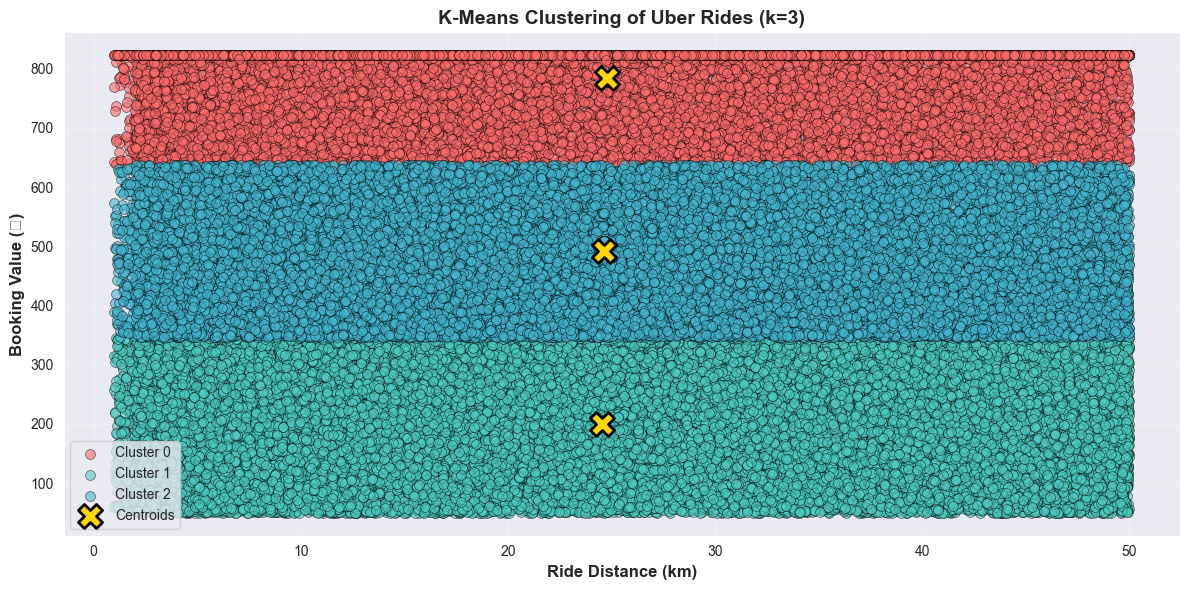

In [57]:
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for cluster in range(3):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    plt.scatter(cluster_data['Ride Distance'],
                cluster_data['Booking Value'],
                c=colors[cluster],
                label=f'Cluster {cluster}',
                s=50,
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5)

plt.scatter(kmeans_model.cluster_centers_[:, 0],
            kmeans_model.cluster_centers_[:, 1],
            c='gold', marker='X', s=300, label='Centroids',
            edgecolors='black', linewidths=2)

plt.xlabel('Ride Distance (km)', fontsize=12, fontweight='bold')
plt.ylabel('Booking Value (₹)', fontsize=12, fontweight='bold')
plt.title('K-Means Clustering of Uber Rides (k=3)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
for cluster in range(3):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    count = len(cluster_data)
    avg_distance = cluster_data['Ride Distance'].mean()
    avg_fare = cluster_data['Booking Value'].mean()

    print(f"\nCluster {cluster}:")
    print(f"  - Trip Count: {count:,}")
    print(f"  - Avg Distance: {avg_distance:.2f} km")
    print(f"  - Avg Booking Value: ₹{avg_fare:.2f}")

    if avg_fare < 300:
        tier = "BUDGET/LOW-VALUE"
    elif avg_fare < 600:
        tier = "MID-VALUE"
    else:
        tier = "PREMIUM/HIGH-VALUE"
    print(f"  - Customer Tier: {tier}")



Cluster 0:
  - Trip Count: 28,894
  - Avg Distance: 24.78 km
  - Avg Booking Value: ₹784.65
  - Customer Tier: PREMIUM/HIGH-VALUE

Cluster 1:
  - Trip Count: 41,303
  - Avg Distance: 24.56 km
  - Avg Booking Value: ₹200.14
  - Customer Tier: BUDGET/LOW-VALUE

Cluster 2:
  - Trip Count: 79,803
  - Avg Distance: 24.63 km
  - Avg Booking Value: ₹492.78
  - Customer Tier: MID-VALUE


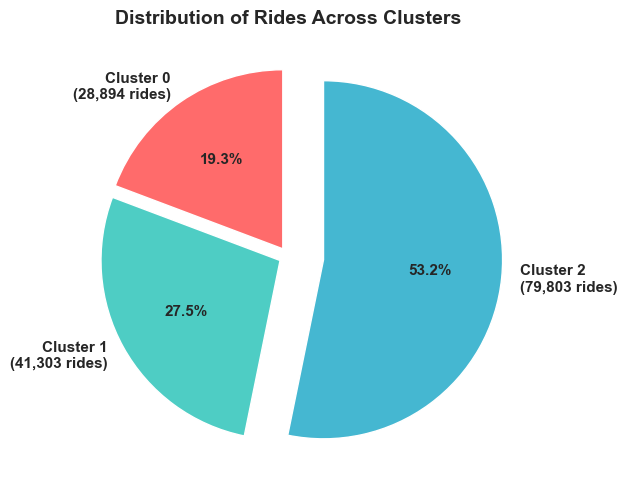

In [59]:
plt.figure(figsize=(10, 5))
cluster_sizes = df['KMeans_Cluster'].value_counts().sort_index()
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode =[0.05, 0.05, 0.2]
plt.pie(cluster_sizes,
        labels=[f'Cluster {i}\n({cluster_sizes[i]:,} rides)' for i in range(3)],
        colors=colors_pie,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode,
        textprops={'fontsize': 11, 'fontweight': 'bold'})

plt.title('Distribution of Rides Across Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

KNN Model (Cancellation Prediction)
  - Use case: Predict which rides will be cancelled
  - Action: Take preventive measures for high-risk bookings

K-Means Clustering (Ride Segmentation)
  - 3 clusters identified
  - Use case: Segment rides by value tier (Budget, Mid, Premium)
  - Action: Tailor marketing, pricing, and driver allocation by tie

**Conclusion**
This study effectively applies K-Means and KNN to Uber’s ride data, achieving:
Clear segmentation of customers by booking value and distance.
Highly accurate prediction of ride cancellations.
These insights enable strategic resource deployment, dynamic pricing, and customer-centric planning.
While model reliability is strong, future work can integrate geographic, temporal, and behavioral features for richer predictions and real-time optimization

### Future Work
- **Add Geospatial Features**: Integrating live geospatial coordinates can enable route-based clustering,travel-time prediction, and surge-demand forecasting.
- I**mprove Clustering with More Features**: Future analysis can apply logistic regression, random forests, or XGBoost to improve cancellation prediction and interpret feature importance.
- **Use PCA for Dimensionality Reduction**


References
- Kaggle Uber Ride Analytics Dashboard (2024)
- Scikit-learn Documentation – KMeans, KNeighborsClassifier
- Standard Data Science Literature – Clustering & Classification Methods

### OpenAI Contribution: 25% (for syntax referring and understanding about new models and their working. ).